# Diagnóstico post-hoc — Smoke neuronal cíclico

El smoke formal produjo `FAIL`: el latent separó perfectamente las fases, pero el predictor no recuperó el espectro cíclico. Este notebook no redefine el gate ni busca convertir ese resultado en `PASS`.

Repetimos exactamente la configuración y seed para comparar: (1) el predictor entrenado online→EMA, (2) un operador least-squares online→online y (3) un operador least-squares online→EMA. Así distinguimos un fallo de representación de un desacople de coordenadas causado por el target encoder rezagado. Test sigue sin construirse.

In [1]:
# ruff: noqa: E402, E501
import json
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Markdown, display

from koopman_jepa.config import DataConfig, ExperimentConfig, ModelConfig, TrainConfig
from koopman_jepa.koopman import expected_active_spectrum
from koopman_jepa.model import TemporalJEPA
from koopman_jepa.phase_analysis import evaluate_phase_operator_diagnostics
from koopman_jepa.phase_data import PhaseWindowConfig, make_phase_tensor_dataset_splits
from koopman_jepa.training import (
    collect_paired_embeddings,
    select_device,
    set_seed,
    train_model_with_validation_checkpoint,
)

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
CONFIG_PATH = ROOT / "configs" / "stage3_cyclic_neural_smoke.yaml"
with CONFIG_PATH.open(encoding="utf-8") as handle:
    raw = yaml.safe_load(handle)
dynamics = raw["dynamics"]
base_seed = int(raw["base_seed"])
emission_config = PhaseWindowConfig(**raw["emission"], repeats_per_transition=1)
model_raw = raw["model"]
experiment_config = ExperimentConfig(
    data=DataConfig(context_length=emission_config.window_length),
    model=ModelConfig(latent_dim=model_raw["latent_dim"], channels=model_raw["channels"], predictor_init=model_raw["predictor_init"]),
    train=TrainConfig(seed=base_seed, **raw["train"]),
)
splits = make_phase_tensor_dataset_splits(
    emission_config,
    train_repeats_per_transition=raw["splits"]["train_repeats_per_transition"],
    validation_repeats_per_transition=raw["splits"]["validation_repeats_per_transition"],
    seed=base_seed,
)
train_dataset = splits.train[dynamics]
validation_dataset = splits.validation[dynamics]
print(json.dumps({"replayed_config": CONFIG_PATH.name, "test_constructed": False}, indent=2))

{
  "replayed_config": "stage3_cyclic_neural_smoke.yaml",
  "test_constructed": false
}


In [3]:
set_seed(base_seed)
device = select_device(experiment_config.train.device)
model = TemporalJEPA(
    latent_dim=model_raw["latent_dim"],
    channels=model_raw["channels"],
    predictor_init=model_raw["predictor_init"],
    pooling=model_raw["pooling"],
    input_length=emission_config.window_length,
).to(device)
training_result = train_model_with_validation_checkpoint(
    model, train_dataset, validation_dataset, experiment_config, device
)
assert training_result.best_epoch == 3
current_online, future_online, future_target, phase_pairs = collect_paired_embeddings(
    model, validation_dataset, experiment_config.train.batch_size, device
)
predictor_matrix = model.predictor.matrix.detach().cpu().numpy()
diagnostics = evaluate_phase_operator_diagnostics(
    current_online=current_online,
    future_online=future_online,
    future_target=future_target,
    current_phases=phase_pairs[:, 0],
    future_phases=phase_pairs[:, 1],
    predictor_matrix=predictor_matrix,
    dynamics=dynamics,
)
serializable = {key: value for key, value in diagnostics.items() if not key.endswith("_operator")}
serializable["trained_predictor_eigenvalues"] = [str(value) for value in np.linalg.eigvals(predictor_matrix)]
serializable["posthoc_online_eigenvalues"] = [str(value) for value in np.linalg.eigvals(diagnostics["posthoc_online_operator"])]
serializable["posthoc_target_eigenvalues"] = [str(value) for value in np.linalg.eigvals(diagnostics["posthoc_target_operator"])]
print(json.dumps(serializable, indent=2))

epoch=001 train=3.505515 val=2.170090


epoch=006 train=0.681096 val=1.682290


epoch=012 train=0.637826 val=1.901009


epoch=018 train=0.534543 val=1.791417


epoch=024 train=0.436637 val=1.552805


epoch=030 train=0.340909 val=1.688299
{
  "online_encoder_phase_basis_error": 0.018740381175835544,
  "online_target_phase_basis_error": 0.8118941987588719,
  "trained_online_endomorphism_error": 1.2791016944174878,
  "trained_cross_encoder_error": 3.3376556835171742,
  "predictor_vs_posthoc_online_error": 1.3015640298940274,
  "predictor_vs_posthoc_target_error": 3.746532331428873,
  "posthoc_online_prediction_error": 0.21508016732065352,
  "posthoc_target_prediction_error": 0.23898590745258963,
  "posthoc_online_spectral_mean_error": 0.03463608804507076,
  "posthoc_online_spectral_max_error": 0.036851139978890425,
  "posthoc_target_spectral_mean_error": 0.8204807428566555,
  "posthoc_target_spectral_max_error": 0.8638724710239176,
  "trained_predictor_eigenvalues": [
    "(-1.2068338+0j)",
    "(0.39177287+0j)",
    "(-0.1244095+0j)"
  ],
  "posthoc_online_eigenvalues": [
    "(-0.003890080750819187+0.9633547576144477j)",
    "(-0.003890080750819187-0.9633547576144477j)",
    "(-0.96

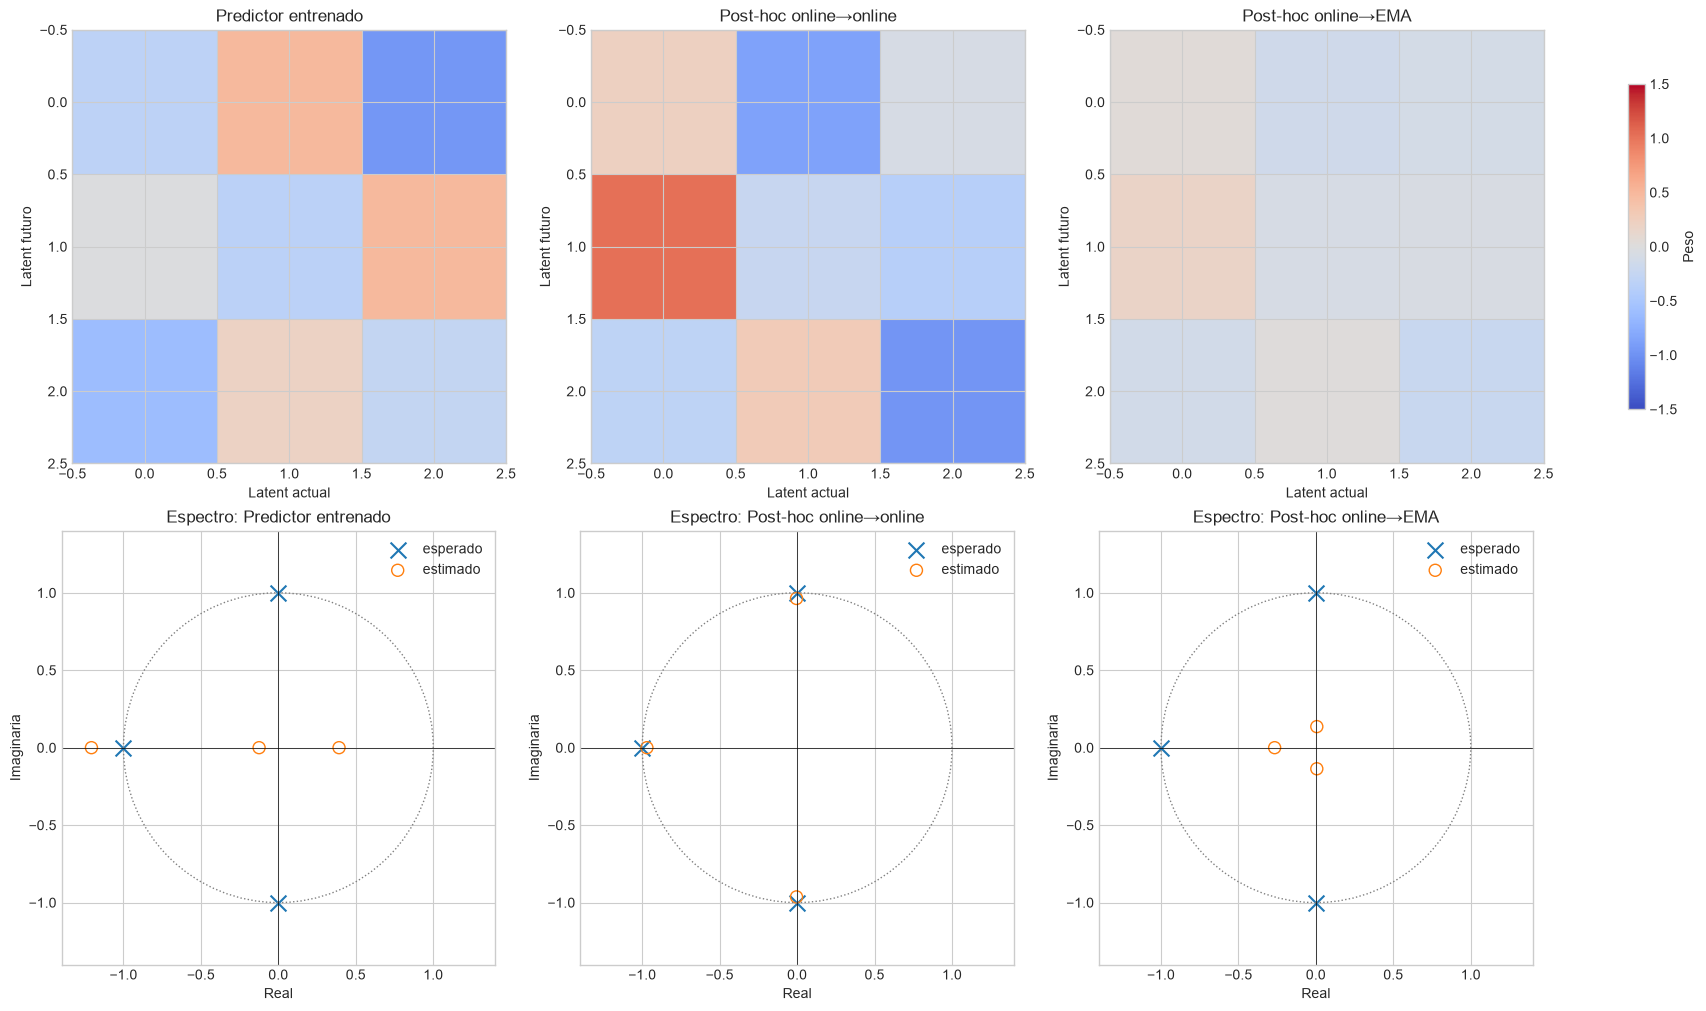

## Lectura diagnóstica

- Error entre bases de fase online actual/futura: **0.019**.
- Error entre las bases online y EMA futuras: **0.812**.
- Error dinámico del predictor como endomorfismo online: **1.279**.
- Error dinámico del predictor en la coordenada online→EMA que entrenó: **3.338**.
- Distancia predictor/post-hoc online: **1.302**.
- Distancia predictor/post-hoc EMA: **3.747**.
- Error espectral máximo post-hoc online / EMA: **0.037 / 0.864**.

Este diagnóstico no altera el `FAIL`. Si el post-hoc online recupera el espectro pero el predictor no, la representación contiene la dinámica y el problema está en interpretar el mapa cruzado online→EMA como un endomorfismo. Si ambos fallan, la separabilidad de fase no se organizó como un subespacio dinámicamente lineal estable.


In [4]:
operators = {
    "Predictor entrenado": predictor_matrix,
    "Post-hoc online→online": diagnostics["posthoc_online_operator"],
    "Post-hoc online→EMA": diagnostics["posthoc_target_operator"],
}
fig, axes = plt.subplots(2, 3, figsize=(17, 10), constrained_layout=True)
for axis, (name, operator) in zip(axes[0], operators.items(), strict=True):
    image = axis.imshow(operator, cmap="coolwarm", vmin=-1.5, vmax=1.5)
    axis.set(title=name, xlabel="Latent actual", ylabel="Latent futuro")
fig.colorbar(image, ax=axes[0].tolist(), shrink=0.75, label="Peso")

expected = expected_active_spectrum(dynamics, emission_config.num_phases)
for axis, (name, operator) in zip(axes[1], operators.items(), strict=True):
    eigenvalues = np.linalg.eigvals(operator)
    axis.scatter(expected.real, expected.imag, marker="x", s=130, label="esperado")
    axis.scatter(eigenvalues.real, eigenvalues.imag, facecolors="none", edgecolors="tab:orange", s=75, label="estimado")
    axis.add_patch(plt.Circle((0, 0), 1, fill=False, linestyle=":", color="gray"))
    axis.axhline(0, color="black", linewidth=0.5)
    axis.axvline(0, color="black", linewidth=0.5)
    axis.set(title=f"Espectro: {name}", xlabel="Real", ylabel="Imaginaria", aspect="equal", xlim=(-1.4, 1.4), ylim=(-1.4, 1.4))
    axis.legend()
plt.show()

display(Markdown(f"""## Lectura diagnóstica

- Error entre bases de fase online actual/futura: **{diagnostics['online_encoder_phase_basis_error']:.3f}**.
- Error entre las bases online y EMA futuras: **{diagnostics['online_target_phase_basis_error']:.3f}**.
- Error dinámico del predictor como endomorfismo online: **{diagnostics['trained_online_endomorphism_error']:.3f}**.
- Error dinámico del predictor en la coordenada online→EMA que entrenó: **{diagnostics['trained_cross_encoder_error']:.3f}**.
- Distancia predictor/post-hoc online: **{diagnostics['predictor_vs_posthoc_online_error']:.3f}**.
- Distancia predictor/post-hoc EMA: **{diagnostics['predictor_vs_posthoc_target_error']:.3f}**.
- Error espectral máximo post-hoc online / EMA: **{diagnostics['posthoc_online_spectral_max_error']:.3f} / {diagnostics['posthoc_target_spectral_max_error']:.3f}**.

Este diagnóstico no altera el `FAIL`. Si el post-hoc online recupera el espectro pero el predictor no, la representación contiene la dinámica y el problema está en interpretar el mapa cruzado online→EMA como un endomorfismo. Si ambos fallan, la separabilidad de fase no se organizó como un subespacio dinámicamente lineal estable.
"""))